# Credit Risk & Loan Portfolio Analysis
### Real LendingClub loans (2007–2011) · Python notebook

**Business problem:** a lender wants to understand the health of its loan portfolio, find the higher-risk customer segments, and see where losses may come from.

**Data:** 42,535 real consumer loans issued by LendingClub, Jun 2007 – Dec 2011 ($460M), with each loan's status and balance at the **snapshot date, 17 Aug 2013**.

| Term | Definition used here |
|---|---|
| **Default** | Loan status *Charged Off* or *Default* |
| **Delinquent** | Active loan *In Grace Period* or *Late* (1–120 days past due) |
| **At-risk loan value** | Principal still outstanding on delinquent + defaulted loans |
| **Matured loans** | 36-month loans issued on or before 17 Aug 2010: their full term ended before the snapshot, so their final outcome is known (no partial-life bias) |

**Workflow:** SQL (database + risk queries) → **Python (EDA, drivers, default-risk model)** → Excel (portfolio workbook + policy simulator) → Power BI (executive dashboard)

## 1. Setup and load from the SQL database

In [1]:
import sqlite3, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
warnings.filterwarnings("ignore")

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
IMG = BASE / "images"; IMG.mkdir(exist_ok=True)
pd.set_option("display.float_format", "{:,.2f}".format)
BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#b5b4ae", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e6e5e0", "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.titleweight": "bold",
                     "axes.titlesize": 12, "axes.edgecolor": GRAY, "font.size": 10})
pctf = mtick.PercentFormatter(1.0, decimals=0)
def save(fig, name):
    fig.tight_layout(); fig.savefig(IMG / f"{name}.png", dpi=150, bbox_inches="tight")

con = sqlite3.connect(BASE / "data" / "credit_risk.db")
df = pd.read_sql("SELECT * FROM vw_loans", con, parse_dates=["issue_date"])
df["matured"] = ((df.term_months == 36) & (df.issue_date <= "2010-08-17")).astype(int)
print(df.shape); df.head(3)

(42535, 51)


,loan_id,member_id,issue_date,issue_year,issue_quarter,funded_amnt,loan_amnt,term_months,int_rate,installment,...,last_payment_date,at_risk_amount,ever_paid_late,fico_band,income_band,dti_band,rate_band,amount_band,emp_band,matured
0,54734,80364,2009-08-05,2009,2009-Q3,25000,25000,36,0.12,829.10,...,2011-10-14,0.00,0,5. 720-739,4. $75-100K,4. 15-20%,3. 11-14%,5. $25K+,1. <1 yr,1
1,55521,107577,2008-07-07,2008,2008-Q3,1000,1000,36,0.16,35.20,...,2010-03-11,0.00,0,1. <660,2. $30-50K,5. 20-25%,4. 14-17%,1. <$5K,1. <1 yr,1
2,55742,114426,2008-05-27,2008,2008-Q2,7000,7000,36,0.11,228.22,...,2011-06-02,0.00,0,4. 700-719,3. $50-75K,3. 10-15%,2. 8-11%,2. $5-10K,1. <1 yr,1


## 2. Data checks
The original file was checked and cleaned by `scripts/01_prepare_data.py`.

In [2]:
display(pd.read_csv(BASE / "data" / "clean" / "cleaning_log.csv"))
print("Loans:", len(df), "| unique IDs:", df.loan_id.nunique(), "| missing FICO:", df.fico_score.isna().sum())

,table,check,rows,action
0,source,"Rows loaded (first line is a text note, skipped)",42535,"42,535 loans, 102 columns"
1,source,Columns that are completely empty,40,dropped (LendingClub added them for later years)
2,source,Duplicate loan IDs,0,none found
3,loans,Loans that did not meet LendingClub's current ...,2749,status prefix removed; kept and flagged in mee...
4,loans,Interest rate stored as text like ' 10.99%',42535,converted to a number (0.1099)
5,borrowers,Employment length missing ('n/a'),1112,left blank; grouped as 'Unknown' in analysis
6,borrowers,FICO given as a range (e.g. 735-739),42535,fico_score = midpoint of the range
7,borrowers,Missing annual income,4,left blank (excluded from income analysis)
8,borrowers,Annual income above $1M,15,kept (self-reported); income bands cap at '$15...
9,borrowers,Home ownership 'NONE',8,merged into 'OTHER'


Loans: 42535 | unique IDs: 42535 | missing FICO: 0


## 3. Portfolio health at a glance

,value
Total loan value (funded),$460.3M
Number of loans,"42,535"
"Default rate (all loans, at snapshot)",10.98%
Lifetime default rate (matured loans),14.32%
Delinquency rate (active loans),5.86%
Average interest rate,12.16%
Outstanding balance,$104.2M
At-risk loan value (delinquent + defaulted balance),$7.60M
At-risk share of outstanding,7.3%
Principal already lost to charge-offs,$37.8M


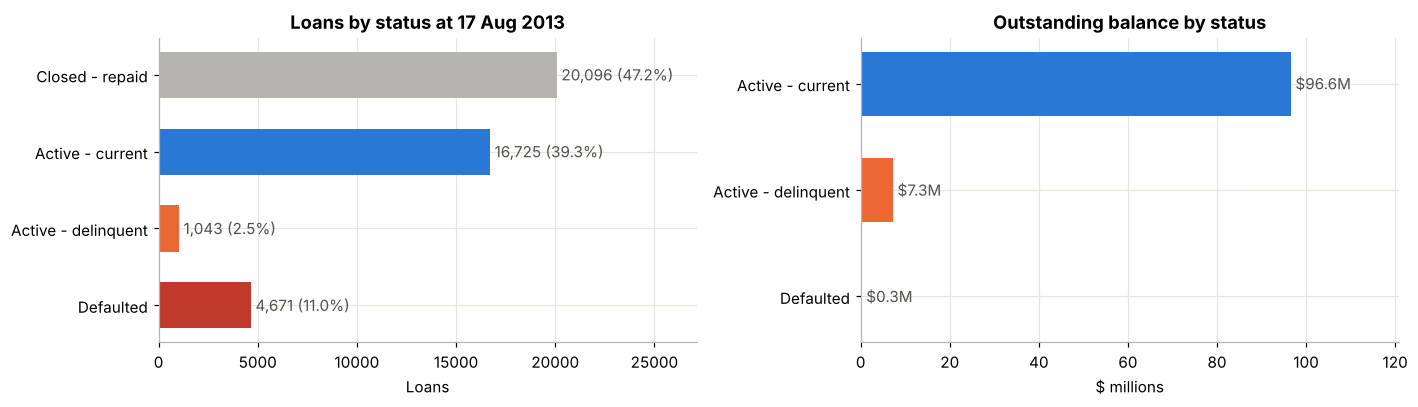

In [3]:
active = df[df.is_active == 1]
kpi = pd.Series({
    "Total loan value (funded)": f"${df.funded_amnt.sum()/1e6:,.1f}M",
    "Number of loans": f"{len(df):,}",
    "Default rate (all loans, at snapshot)": f"{df.is_default.mean():.2%}",
    "Lifetime default rate (matured loans)": f"{df[df.matured == 1].is_default.mean():.2%}",
    "Delinquency rate (active loans)": f"{active.is_delinquent.mean():.2%}",
    "Average interest rate": f"{df.int_rate.mean():.2%}",
    "Outstanding balance": f"${df.out_prncp.sum()/1e6:,.1f}M",
    "At-risk loan value (delinquent + defaulted balance)": f"${df.at_risk_amount.sum()/1e6:,.2f}M",
    "At-risk share of outstanding": f"{df.at_risk_amount.sum()/df.out_prncp.sum():.1%}",
    "Principal already lost to charge-offs": f"${df.principal_lost.sum()/1e6:,.1f}M",
})
display(kpi.to_frame("value"))

st = df.groupby("status_group").agg(loans=("loan_id", "size"), outstanding=("out_prncp", "sum"))
order = ["Closed - repaid", "Active - current", "Active - delinquent", "Defaulted"]
st = st.reindex(order)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
cols = [GRAY, BLUE, ORANGE, "#c0392b"]
ax[0].barh(order[::-1], st.loans[::-1], color=cols[::-1], height=0.6)
for i, v in enumerate(st.loans[::-1]): ax[0].text(v, i, f" {v:,} ({v/len(df):.1%})", va="center", color=INK)
ax[0].set(title="Loans by status at 17 Aug 2013", xlabel="Loans"); ax[0].set_xlim(0, st.loans.max() * 1.35)
ob = st.outstanding.drop("Closed - repaid")
ax[1].barh(ob.index[::-1], ob[::-1] / 1e6, color=cols[1:][::-1], height=0.6)
for i, v in enumerate(ob[::-1]): ax[1].text(v / 1e6, i, f" ${v/1e6:,.1f}M", va="center", color=INK)
ax[1].set(title="Outstanding balance by status", xlabel="$ millions"); ax[1].set_xlim(0, ob.max() / 1e6 * 1.25)
save(fig, "01_portfolio_status"); plt.show()

**Insight — portfolio health:**
- $460M lent across 42,535 loans. At the snapshot **47% are fully repaid, 39% are current, 2.4% are delinquent and 11.0% have defaulted**.
- Among loans that have run their full term, the **lifetime default rate is 14.3%**: roughly **1 in 7 loans defaults** over its life.
- **$37.8M of principal (8.2% of everything lent) has already been lost** to charge-offs.
- Of the **$104.2M still outstanding**, **$7.6M (7.3%) is already delinquent or in default**.

## 4. Which customers default most?

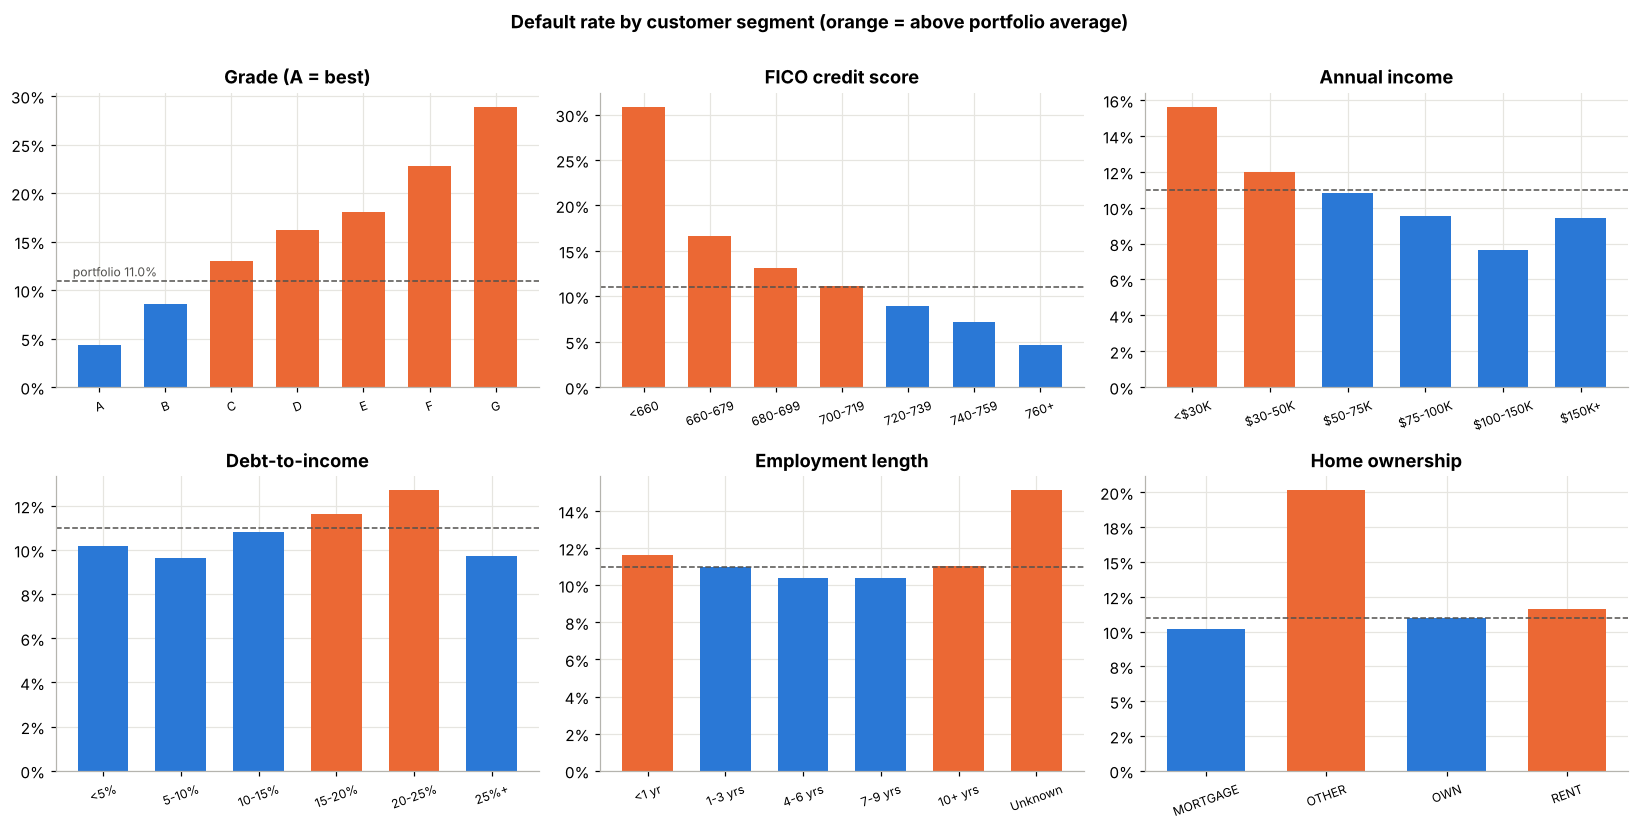

Highest-default customer segments (min. 100 loans):


In [4]:
def rate(col, data=df, min_n=100):
    g = data.groupby(col).agg(loans=("loan_id", "size"), default_rate=("is_default", "mean"))
    return g[g.loans >= min_n]

panels = [("grade", "Grade (A = best)"), ("fico_band", "FICO credit score"), ("income_band", "Annual income"),
          ("dti_band", "Debt-to-income"), ("emp_band", "Employment length"), ("home_ownership", "Home ownership")]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
overall = df.is_default.mean()
for ax, (col, ttl) in zip(axes.flat, panels):
    r = rate(col)
    labels = [str(x).split(". ", 1)[-1] for x in r.index]
    ax.bar(labels, r.default_rate, color=[ORANGE if v > overall else BLUE for v in r.default_rate], width=0.65)
    ax.axhline(overall, color=INK, ls="--", lw=1)
    ax.yaxis.set_major_formatter(pctf); ax.set_title(ttl); ax.tick_params(axis="x", labelsize=8, rotation=20)
axes[0, 0].text(-0.4, overall * 1.04, f"portfolio {overall:.1%}", color=INK, fontsize=8)
fig.suptitle("Default rate by customer segment (orange = above portfolio average)", fontweight="bold", y=1.0)
save(fig, "02_default_by_segment"); plt.show()

seg = pd.concat({c: rate(c) for c, _ in panels})
print("Highest-default customer segments (min. 100 loans):")
display(seg.sort_values("default_rate", ascending=False).head(8).style.format({"default_rate": "{:.1%}", "loans": "{:,}"}))

**Insight — which customer groups default most?**
- **Credit score is the clearest divider.** FICO below 660 defaults at **30.9%** and 660–679 at 16.7%, versus **4.6% for 760+**, a 3.6× gap between the 660–679 and 760+ bands.
- **LendingClub's grade ranks risk well:** grade A 4.3% → grade G **28.9%** (6.7×).
- **Lower income means higher risk:** under $30K defaults at **15.6%**, double the $100–150K band (7.7%). Borrowers with **3+ credit inquiries** in the last 6 months default at **20.1%**, versus 8.1% with none.
- Loans that **did not meet LendingClub's credit policy** default at **26.5%**, versus 9.9%.
- Debt-to-income, home ownership and employment length matter much less (within about ±2 points of average).

## 5. Which loan types carry the greatest risk?

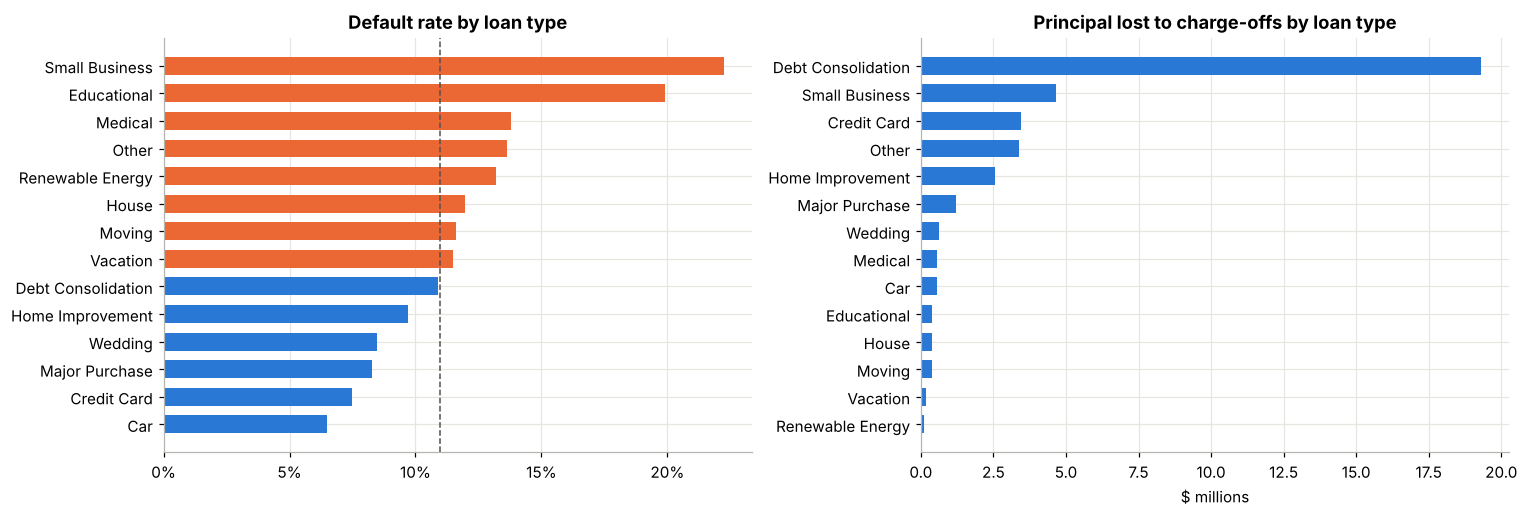

,loans,default_rate,delinquency_rate,share_of_outstanding,share_of_at_risk
term_months,,,,,
36,"31,534",10.2%,5.6%,33%,30%
60,"11,001",13.1%,6.2%,67%,70%


In [5]:
lt = df.groupby("loan_type").agg(loans=("loan_id", "size"), value=("funded_amnt", "sum"),
                                 default_rate=("is_default", "mean"), lost=("principal_lost", "sum"),
                                 at_risk=("at_risk_amount", "sum")).sort_values("default_rate")
lt["share_of_value"] = lt.value / lt.value.sum()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].barh(lt.index, lt.default_rate, color=[ORANGE if v > overall else BLUE for v in lt.default_rate], height=0.65)
ax[0].axvline(overall, color=INK, ls="--", lw=1); ax[0].xaxis.set_major_formatter(pctf)
ax[0].set(title="Default rate by loan type")
l2 = lt.sort_values("lost")
ax[1].barh(l2.index, l2.lost / 1e6, color=BLUE, height=0.65)
ax[1].set(title="Principal lost to charge-offs by loan type", xlabel="$ millions")
save(fig, "03_loan_type_risk"); plt.show()

tm = df.groupby("term_months").agg(loans=("loan_id", "size"), default_rate=("is_default", "mean"),
                                   delinquency=("is_delinquent", "sum"), active=("is_active", "sum"),
                                   outstanding=("out_prncp", "sum"), at_risk=("at_risk_amount", "sum"))
tm["delinquency_rate"] = tm.delinquency / tm.active
tm["share_of_outstanding"] = tm.outstanding / tm.outstanding.sum()
tm["share_of_at_risk"] = tm.at_risk / tm.at_risk.sum()
display(tm[["loans", "default_rate", "delinquency_rate", "share_of_outstanding", "share_of_at_risk"]]
        .style.format({"loans": "{:,}", "default_rate": "{:.1%}", "delinquency_rate": "{:.1%}",
                       "share_of_outstanding": "{:.0%}", "share_of_at_risk": "{:.0%}"}))

**Insight — which loan types carry the greatest risk?**
- **Small business loans are the riskiest: 22.2% default rate**, twice the portfolio average. They cost **$4.7M in principal** from only 5.7% of the money lent.
- Educational (19.9%) and medical (13.8%) loans follow. **Car (6.5%) and credit card refinancing (7.5%)** are the safest.
- **Debt consolidation is the biggest exposure, not the riskiest.** It is 53% of lending at a near-average 10.9% default rate, but it carries **51% of all principal lost ($19.3M)** and **60% of today's at-risk balance**.
- **60-month loans** default more (13.1% vs 10.2%). They are only 26% of loans but hold **67% of the outstanding balance and 70% of the at-risk value**.

## 6. Is a higher interest rate associated with higher default — and is it worth it?
Interest rates are set from the grade, so rate and default rise together. The real question for the business is whether the **extra interest covers the extra losses**. That can only be judged on **matured loans**, where every final outcome is known.

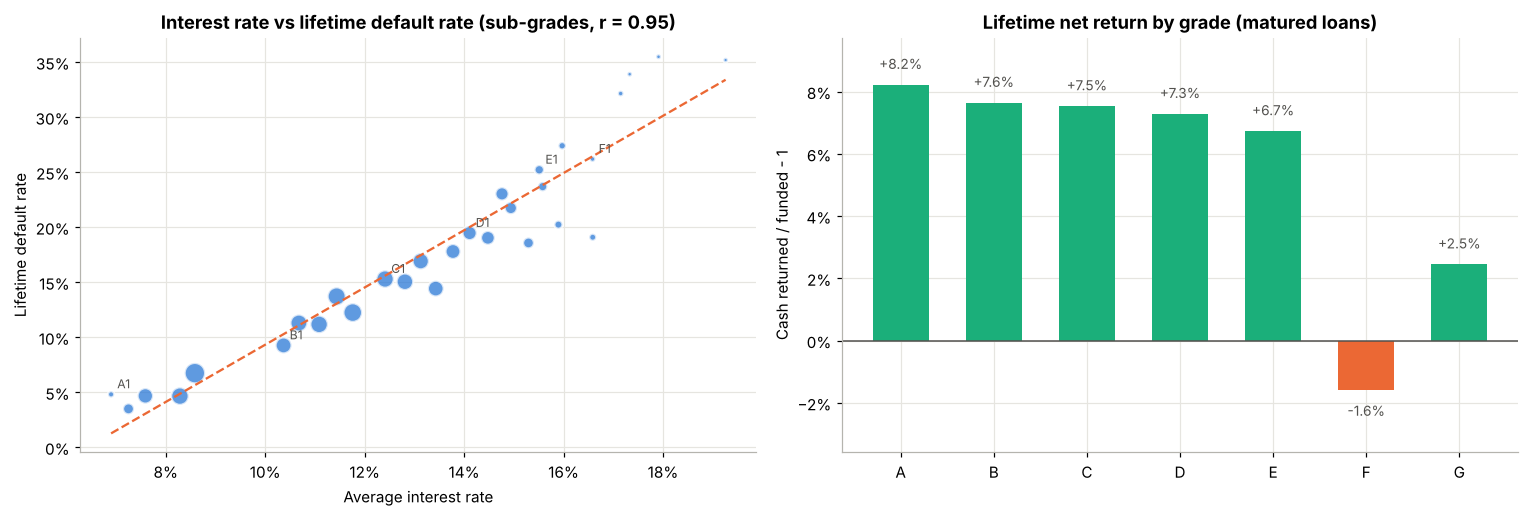

,loans,rate,dr,net_return
grade,,,,
A,"2,920",8.09%,5.3%,+8.22%
B,"3,953",11.12%,11.7%,+7.65%
C,"3,419",13.06%,15.8%,+7.54%
D,"2,172",14.65%,20.4%,+7.29%
E,912,15.83%,23.4%,+6.73%
F,333,17.30%,32.7%,-1.59%
G,194,18.76%,35.6%,+2.45%


In [6]:
mat = df[df.matured == 1]
sg = mat.groupby("sub_grade").agg(loans=("loan_id", "size"), rate=("int_rate", "mean"), dr=("is_default", "mean"))
sg = sg[sg.loans >= 50]
r_corr = np.corrcoef(sg.rate, sg.dr)[0, 1]
gr = mat.groupby("grade").agg(loans=("loan_id", "size"), rate=("int_rate", "mean"), dr=("is_default", "mean"),
                              paid=("total_pymnt", "sum"), funded=("funded_amnt", "sum"))
gr["net_return"] = gr.paid / gr.funded - 1

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].scatter(sg.rate, sg.dr, s=sg.loans / 6, color=BLUE, alpha=0.75, edgecolor="white", linewidth=1.5)
b = np.polyfit(sg.rate, sg.dr, 1); xs = np.linspace(sg.rate.min(), sg.rate.max(), 50)
ax[0].plot(xs, np.polyval(b, xs), color=ORANGE, lw=1.5, ls="--")
for s_, r_ in sg.iloc[::5].iterrows(): ax[0].annotate(s_, (r_.rate, r_.dr), xytext=(4, 4), textcoords="offset points", fontsize=8, color=INK)
ax[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); ax[0].yaxis.set_major_formatter(pctf)
ax[0].set(title=f"Interest rate vs lifetime default rate (sub-grades, r = {r_corr:.2f})",
          xlabel="Average interest rate", ylabel="Lifetime default rate")
ax[1].bar(gr.index, gr.net_return, color=[AQUA if v > 0 else ORANGE for v in gr.net_return], width=0.6)
ax[1].axhline(0, color=INK, lw=1); ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
for i, (g_, r_) in enumerate(gr.iterrows()):
    ax[1].text(i, r_.net_return + (0.004 if r_.net_return >= 0 else -0.004), f"{r_.net_return:+.1%}",
               ha="center", va="bottom" if r_.net_return >= 0 else "top", color=INK, fontsize=9)
ax[1].set_ylim(gr.net_return.min() - 0.02, gr.net_return.max() + 0.015)
ax[1].set(title="Lifetime net return by grade (matured loans)", ylabel="Cash returned / funded - 1")
save(fig, "04_rate_vs_default"); plt.show()
display(gr[["loans", "rate", "dr", "net_return"]].style.format({"loans": "{:,}", "rate": "{:.2%}", "dr": "{:.1%}", "net_return": "{:+.2%}"}))

**Insight — higher interest rates go with higher default (r = 0.95 across sub-grades).** Lifetime default climbs from **5% for A-grade loans to 36% for G**.

**Does the higher rate pay for the extra risk?** For grades **A–E, yes**: lifetime net returns stay between **+6.7% and +8.2%**. For **grade F the extra interest does not cover the losses (−1.6%)**, and grade G returns only +2.5% on a small sample. The safest grade (A) actually earned the **highest** net return. (Returns exclude post-charge-off recoveries, which this file does not contain, so they are slightly conservative.)

## 7. Default trend over time and geography

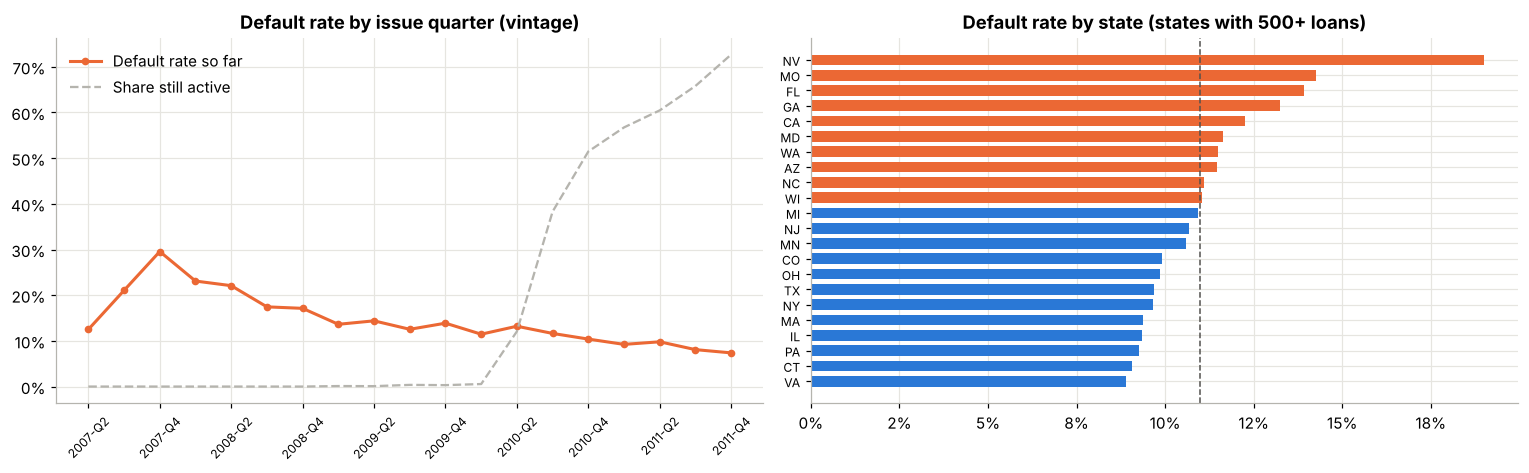

,loans,dr,at_risk
region,,,
West,"12,043",12.2%,"$2,098,084"
South,"13,940",11.1%,"$2,346,970"
Midwest,"6,136",10.7%,"$1,146,070"
Northeast,"10,416",9.7%,"$2,006,139"


In [7]:
q = df.groupby("issue_quarter").agg(loans=("loan_id", "size"), dr=("is_default", "mean"), active=("is_active", "mean"))
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
x = np.arange(len(q))
ax[0].plot(x, q.dr, color=ORANGE, lw=2, marker="o", ms=4, label="Default rate so far")
ax[0].plot(x, q.active, color=GRAY, lw=1.5, ls="--", label="Share still active")
ax[0].set_xticks(x[::2], q.index[::2], rotation=45, fontsize=8); ax[0].yaxis.set_major_formatter(pctf)
ax[0].legend(frameon=False); ax[0].set(title="Default rate by issue quarter (vintage)")

stt = df.groupby(["state", "state_name"]).agg(loans=("loan_id", "size"), dr=("is_default", "mean")).reset_index()
stt = stt[stt.loans >= 500].sort_values("dr")
ax[1].barh(stt.state, stt.dr, color=[ORANGE if v > overall else BLUE for v in stt.dr], height=0.7)
ax[1].axvline(overall, color=INK, ls="--", lw=1); ax[1].xaxis.set_major_formatter(pctf)
ax[1].set(title="Default rate by state (states with 500+ loans)"); ax[1].tick_params(axis="y", labelsize=8)
save(fig, "05_trend_and_geography"); plt.show()
reg = df.groupby("region").agg(loans=("loan_id", "size"), dr=("is_default", "mean"), at_risk=("at_risk_amount", "sum"))
display(reg.sort_values("dr", ascending=False).style.format({"loans": "{:,}", "dr": "{:.1%}", "at_risk": "${:,.0f}"}))

**Insight — trend and geography:**
- **Default rates fell steadily by vintage:** loans issued in **2007 defaulted at 26%** and 2008 at 21% (made just before and during the financial crisis), then 13.6% in 2009 and 11.6% in 2010. 2011 shows 8.5% so far, but **65% of 2011 loans are still active**, so that figure will rise.
- **Nevada (19.0%), Missouri (14.3%), Florida (13.9%) and Georgia (13.2%)** have the highest default rates among states with 500+ loans. Nevada and Florida were hit hardest by the housing crash.
- **California** has an average rate (12.3%) but, as the biggest state (17% of loans), holds the **largest at-risk balance ($1.4M)**. The **West** is the riskiest region (12.2%) and the **Northeast** the safest (9.7%).

## 8. Default-risk model
**Goal:** score every loan with a probability of default (PD) from information known **when the loan was made**: credit score, income, debt-to-income, employment, home ownership, credit history, loan amount, term, purpose and interest rate. Nothing from after the loan was issued is used, so there is no leakage.

**Target — "bad within 24 months":** the standard credit-risk *performance window*. A loan is *bad* if it defaulted with its last payment within 24 months of issue. Every loan issued on or before 17 Aug 2011 has had a full 24 months to show this, so **36- and 60-month loans are judged on equal terms** (simply using finished loans would overstate 60-month risk, because their early endings are mostly defaults). Data: 75% train / 25% test, stratified.

32,752 loans with a full 24-month window; bad within 24 months: 10.2%
term_months
36     9.4%
60    12.7%


,ROC-AUC (test set)
Logistic regression,0.707
Gradient boosting,0.703
LendingClub grade alone,0.661
FICO score alone,0.622


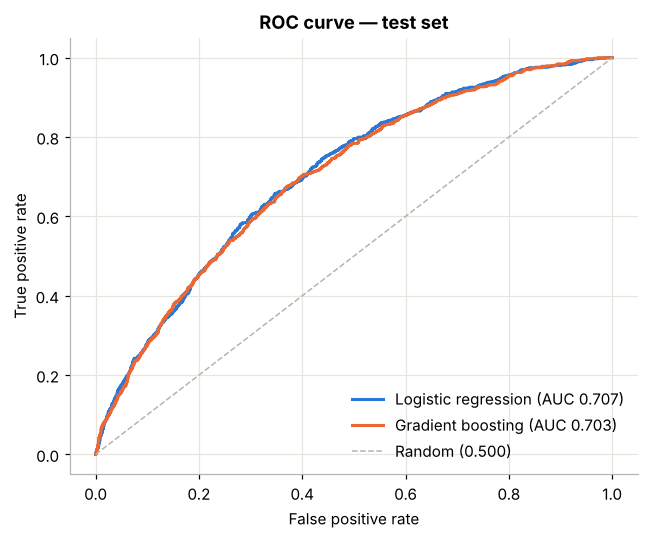

In [8]:
df["last_payment_date"] = pd.to_datetime(df.last_payment_date)
res = df[df.issue_date <= "2011-08-17"].copy()
res["bad_24m"] = ((res.is_default == 1) & (res.last_payment_date.isna() |
                  (res.last_payment_date <= res.issue_date + pd.DateOffset(months=24)))).astype(int)
print(f"{len(res):,} loans with a full 24-month window; bad within 24 months: {res.bad_24m.mean():.1%}")
print(res.groupby("term_months").bad_24m.mean().map("{:.1%}".format).to_string())
def features(d):
    X = pd.DataFrame({
        "fico_score": d.fico_score, "log_income": np.log1p(d.annual_inc), "dti": d.dti,
        "emp_length_years": d.emp_length_years, "inq_last_6mths": d.inq_last_6mths, "revol_util": d.revol_util,
        "delinq_2yrs": d.delinq_2yrs, "pub_rec": d.pub_rec, "credit_history_years": d.credit_history_years,
        "log_amount": np.log(d.funded_amnt), "loan_to_income": d.funded_amnt / d.annual_inc.replace(0, np.nan),
        "int_rate": d.int_rate, "term_60": (d.term_months == 60).astype(int),
        "home_ownership": d.home_ownership, "loan_type": d.loan_type,
    })
    return X
num = ["fico_score", "log_income", "dti", "emp_length_years", "inq_last_6mths", "revol_util", "delinq_2yrs", "pub_rec",
       "credit_history_years", "log_amount", "loan_to_income", "int_rate", "term_60"]
cat = ["home_ownership", "loan_type"]
X, y = features(res), res.bad_24m
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

pre = ColumnTransformer([("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num),
                         ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), cat)])
models = {
    "Logistic regression": Pipeline([("pre", pre), ("m", LogisticRegression(max_iter=2000, C=0.5))]),
    "Gradient boosting": Pipeline([("pre", pre), ("m", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                                                                       max_leaf_nodes=15, l2_regularization=1.0,
                                                                                       random_state=42))]),
}
auc, probs = {}, {}
for n, m in models.items():
    m.fit(X_tr, y_tr); probs[n] = m.predict_proba(X_te)[:, 1]; auc[n] = roc_auc_score(y_te, probs[n])
grade_auc = roc_auc_score(y_te, res.loc[X_te.index, "grade"].map({g: i for i, g in enumerate("ABCDEFG")}))
fico_auc = roc_auc_score(y_te, -res.loc[X_te.index, "fico_score"])
comp = pd.Series({**auc, "LendingClub grade alone": grade_auc, "FICO score alone": fico_auc}).sort_values(ascending=False)
display(comp.to_frame("ROC-AUC (test set)").style.format("{:.3f}"))

fig, ax = plt.subplots(figsize=(6, 5))
for (n, p), c in zip(probs.items(), [BLUE, ORANGE]):
    f, t, _ = roc_curve(y_te, p); ax.plot(f, t, color=c, lw=2, label=f"{n} (AUC {auc[n]:.3f})")
ax.plot([0, 1], [0, 1], color=GRAY, ls="--", lw=1, label="Random (0.500)")
ax.set(title="ROC curve — test set", xlabel="False positive rate", ylabel="True positive rate"); ax.legend(frameon=False, loc="lower right")
save(fig, "06_roc_curve"); plt.show()

Model used for scoring: Logistic regression


,loans,actual_default,avg_score,capture
decile,,,,
1,819,2.0%,2.9%,100%
2,819,3.5%,4.3%,98%
3,819,4.2%,5.5%,95%
4,818,6.4%,6.6%,91%
5,819,7.7%,7.9%,84%
6,819,10.0%,9.4%,77%
7,818,11.0%,11.0%,67%
8,819,16.0%,13.3%,56%
9,819,15.9%,16.4%,40%


Riskiest 20% of test loans hold 40% of all test-set defaults; safest 20% hold 5%


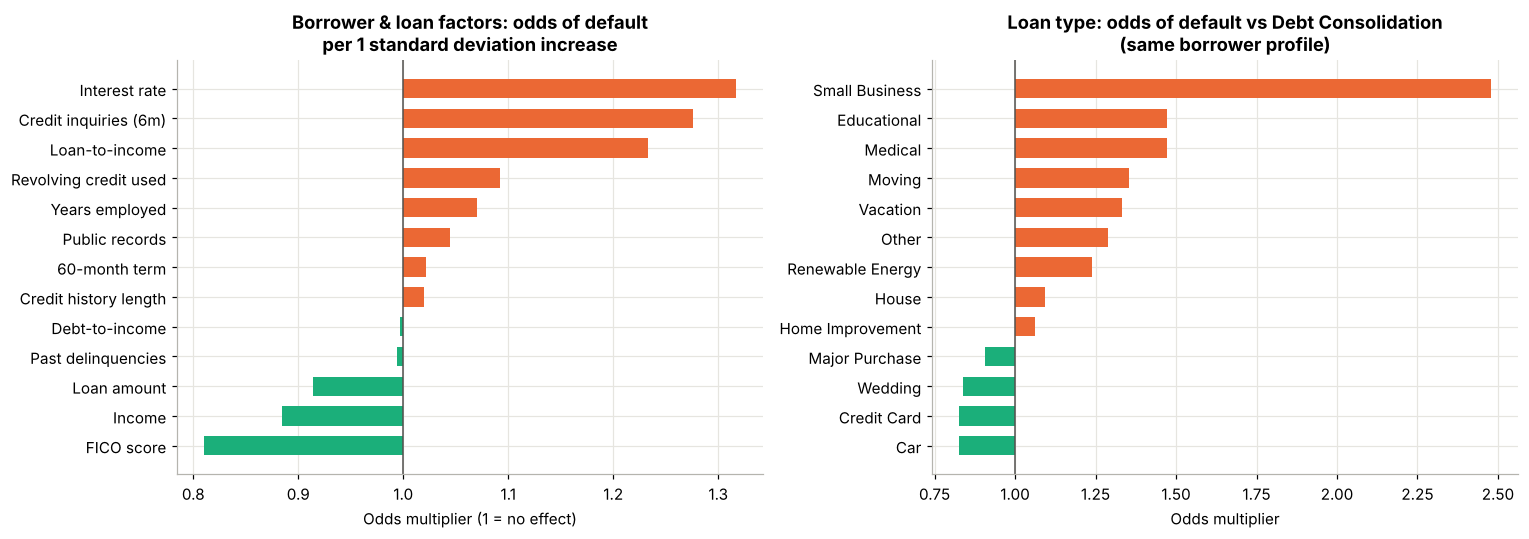

In [9]:
best_name = max(auc, key=auc.get); best = models[best_name]
print("Model used for scoring:", best_name)
# lift table: test loans split into 10 equal groups by predicted risk
t = pd.DataFrame({"p": probs[best_name], "y": y_te.values})
t["decile"] = pd.qcut(t.p.rank(method="first"), 10, labels=range(1, 11))
lift = t.groupby("decile", observed=True).agg(loans=("y", "size"), actual_default=("y", "mean"), avg_score=("p", "mean"))
lift["capture"] = t.groupby("decile", observed=True).y.sum()[::-1].cumsum()[::-1] / t.y.sum()
display(lift.style.format({"actual_default": "{:.1%}", "avg_score": "{:.1%}", "capture": "{:.0%}"}))
top20 = t[t.decile.astype(int) >= 9].y.sum() / t.y.sum(); low20 = t[t.decile.astype(int) <= 2].y.sum() / t.y.sum()
print(f"Riskiest 20% of test loans hold {top20:.0%} of all test-set defaults; safest 20% hold {low20:.0%}")

# what drives the model? (logistic regression, easy to explain)
lr = models["Logistic regression"]
names = num + list(lr.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(cat))
coef = pd.Series(lr.named_steps["m"].coef_[0], index=names)
label = {"fico_score": "FICO score", "log_income": "Income", "dti": "Debt-to-income", "emp_length_years": "Years employed",
         "inq_last_6mths": "Credit inquiries (6m)", "revol_util": "Revolving credit used", "delinq_2yrs": "Past delinquencies",
         "pub_rec": "Public records", "credit_history_years": "Credit history length", "log_amount": "Loan amount",
         "loan_to_income": "Loan-to-income", "int_rate": "Interest rate", "term_60": "60-month term"}
odds = np.exp(coef[num]).rename(index=label).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].barh(odds.index, odds.values - 1, left=1, color=[ORANGE if v > 1 else AQUA for v in odds.values], height=0.65)
ax[0].axvline(1, color=INK, lw=1)
ax[0].set(title="Borrower & loan factors: odds of default\nper 1 standard deviation increase", xlabel="Odds multiplier (1 = no effect)")
lt_coef = coef[[n for n in names if n.startswith("loan_type_")]]
base = lt_coef.get("loan_type_Debt Consolidation", 0)
lt_odds = np.exp(lt_coef - base).rename(lambda n: n.replace("loan_type_", "")).drop("Debt Consolidation", errors="ignore").sort_values()
ax[1].barh(lt_odds.index, lt_odds.values - 1, left=1, color=[ORANGE if v > 1 else AQUA for v in lt_odds.values], height=0.65)
ax[1].axvline(1, color=INK, lw=1)
ax[1].set(title="Loan type: odds of default vs Debt Consolidation\n(same borrower profile)", xlabel="Odds multiplier")
save(fig, "07_default_drivers"); plt.show()

**Insight — default-risk model:**
- The logistic regression ranks risk better than LendingClub's own grade: **ROC-AUC 0.707 vs 0.661** (grade) and 0.622 (FICO alone).
- The **riskiest 10% of loans went bad at 25.3%** within 24 months, versus **2.0% for the safest 10%** (12× apart). The **riskiest 20% hold 40% of all bad loans**.
- **What raises risk:** a higher interest rate (a proxy for the lender's own risk view), more recent credit inquiries, and a larger loan relative to income.
- **What lowers risk:** a higher FICO score and higher income. Holding everything else equal, **small business loans have 2.5× the odds of going bad** compared with debt consolidation.

## 9. How much of the portfolio is at risk?
Three layers of risk in the **$104M still outstanding** at the snapshot:
1. **Already in trouble:** delinquent or in default (the at-risk loan value).
2. **Watchlist:** loans still current but scoring as high as the riskiest 10% of test loans.
3. **Already lost:** principal written off on charged-off loans (history, not outstanding).

Watchlist threshold: risk score >= 18.8%
Sanity check on loans the model never saw as outcomes: average score
status_group
Active - current        9.8%
Active - delinquent    12.8%
Defaulted              12.0%


,outstanding,share_of_outstanding
Delinquent (1-120 days late),"$7,301,875",7.0%
In default (121+ days),"$295,388",0.3%
Watchlist: current but high risk score,"$12,776,917",12.3%
Total potentially at risk,"$20,374,180",19.5%


Outstanding balance: $104.2M | already lost to charge-offs: $37.8M (8.2% of all money lent)


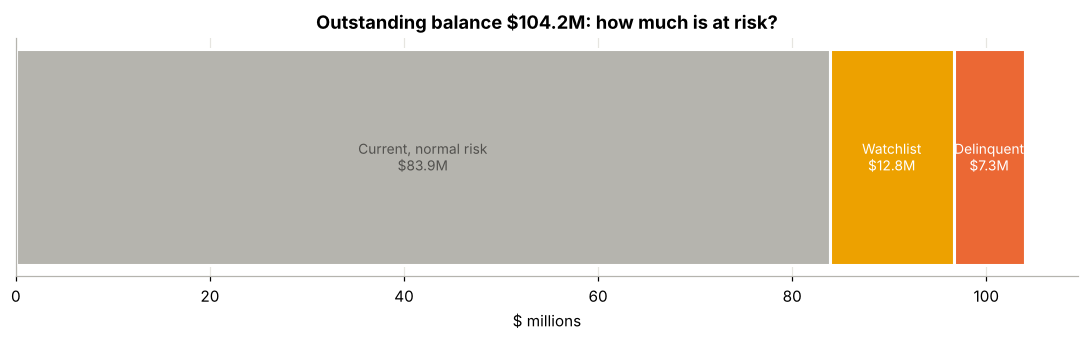

Watchlist profile vs all current loans:


,Watchlist,All current
Avg FICO,684.65,717.35
Avg interest rate,0.18,0.12
Share 60-month,0.76,0.40
Avg DTI,14.70,13.91
Loans,"1,431.00","16,725.00"


In [10]:
df["risk_score"] = best.predict_proba(features(df))[:, 1]
# watchlist threshold = entry point of the riskiest 10% of test loans
cut = t.p.quantile(0.90)
print(f"Watchlist threshold: risk score >= {cut:.1%}")
df["risk_band"] = pd.cut(df.risk_score.rank(pct=True), [0, 0.4, 0.8, 0.95, 1.0],
                         labels=["Low", "Medium", "High", "Very high"]).astype(str)
df["watchlist"] = ((df.loan_status == "Current") & (df.risk_score >= cut)).astype(int)
act = df[df.is_active == 1]
chk = act.groupby("status_group").risk_score.mean()
print("Sanity check on loans the model never saw as outcomes: average score")
print(chk.map("{:.1%}".format).to_string())

layers = pd.Series({
    "Delinquent (1-120 days late)": act.loc[act.is_delinquent == 1, "out_prncp"].sum(),
    "In default (121+ days)": act.loc[act.loan_status == "Default", "out_prncp"].sum(),
    "Watchlist: current but high risk score": act.loc[act.watchlist == 1, "out_prncp"].sum(),
})
outstanding = act.out_prncp.sum()
tbl = layers.to_frame("outstanding"); tbl["share_of_outstanding"] = tbl.outstanding / outstanding
tbl.loc["Total potentially at risk"] = [layers.sum(), layers.sum() / outstanding]
display(tbl.style.format({"outstanding": "${:,.0f}", "share_of_outstanding": "{:.1%}"}))
print(f"Outstanding balance: ${outstanding/1e6:,.1f}M | already lost to charge-offs: ${df.principal_lost.sum()/1e6:,.1f}M "
      f"({df.principal_lost.sum()/df.funded_amnt.sum():.1%} of all money lent)")

fig, ax = plt.subplots(figsize=(10, 3.2))
left = 0
parts = [("Current, normal risk", outstanding - layers.sum(), GRAY), ("Watchlist", layers.iloc[2], "#eda100"),
         ("Delinquent", layers.iloc[0], ORANGE), ("Default", layers.iloc[1], "#c0392b")]
for lab, v, c in parts:
    ax.barh([0], [v / 1e6], left=left, color=c, height=0.5, edgecolor="white", linewidth=2)
    if v / outstanding > 0.03: ax.text(left + v / 2e6, 0, f"{lab}\n${v/1e6:,.1f}M", ha="center", va="center", fontsize=9,
                                     color="white" if c != GRAY else INK)
    left += v / 1e6
ax.set_yticks([]); ax.set(title=f"Outstanding balance ${outstanding/1e6:,.1f}M: how much is at risk?", xlabel="$ millions")
ax.grid(axis="y", visible=False)
save(fig, "08_at_risk_layers"); plt.show()

wl = act[act.watchlist == 1]
print("Watchlist profile vs all current loans:")
display(pd.DataFrame({"Watchlist": [wl.fico_score.mean(), wl.int_rate.mean(), (wl.term_months == 60).mean(), wl.dti.mean(), len(wl)],
                      "All current": [act[act.loan_status == "Current"].fico_score.mean(), act[act.loan_status == "Current"].int_rate.mean(),
                                      (act[act.loan_status == "Current"].term_months == 60).mean(), act[act.loan_status == "Current"].dti.mean(),
                                      (act.loan_status == "Current").sum()]},
                     index=["Avg FICO", "Avg interest rate", "Share 60-month", "Avg DTI", "Loans"]).style.format("{:,.2f}"))

**Insight — how much of the portfolio is potentially at risk?**
| Layer | Outstanding | Share of $104.2M |
|---|---|---|
| Delinquent (1–120 days late) | $7.3M | 7.0% |
| In default (121+ days) | $0.3M | 0.3% |
| Watchlist: current but high risk score | $12.8M | 12.3% |
| **Total potentially at risk** | **$20.4M** | **19.5%** |

The **1,431 watchlist loans** look clearly weaker than other current loans: average FICO 685 vs 717, average rate 18% vs 12%, and **76% are 60-month loans**. Validation on loans the model was not trained to judge: **delinquent loans score higher (12.8%) than current loans (9.8%)**, so the score picks up real stress.

## 10. What if we tightened lending rules? (policy simulation on matured loans)
Each rule removes a group of past loans. On matured loans, where the full outcome is known, we compare **how much lending volume would be lost** with **how many defaults would be avoided** and what happens to the **net return** of the remaining book.

In [11]:
rules = {
    "No rule (actual book)": pd.Series(False, index=mat.index),
    "Decline FICO < 660": mat.fico_score < 660,
    "Decline grades F-G": mat.grade.isin(["F", "G"]),
    "Decline 3+ inquiries in 6 months": mat.inq_last_6mths >= 3,
    "Decline small business loans": mat.loan_type == "Small Business",
    "Decline loans failing credit policy": mat.meets_credit_policy == 0,
    "Combined: F-G, 3+ inquiries, failing policy": mat.grade.isin(["F", "G"]) | (mat.inq_last_6mths >= 3) | (mat.meets_credit_policy == 0),
}
rows = []
for name, drop in rules.items():
    keep = mat[~drop]; gone = mat[drop]
    rows.append({"rule": name, "loans_declined_pct": drop.mean(),
                 "volume_declined": gone.funded_amnt.sum(),
                 "default_rate_after": keep.is_default.mean(),
                 "defaults_avoided_pct": gone.is_default.sum() / mat.is_default.sum(),
                 "default_rate_of_declined": gone.is_default.mean() if len(gone) else np.nan,
                 "net_return_after": keep.total_pymnt.sum() / keep.funded_amnt.sum() - 1,
                 "net_return_of_declined": gone.total_pymnt.sum() / gone.funded_amnt.sum() - 1 if len(gone) else np.nan})
pol = pd.DataFrame(rows).set_index("rule")
display(pol.style.format({"loans_declined_pct": "{:.1%}", "volume_declined": "${:,.0f}", "default_rate_after": "{:.2%}",
                          "defaults_avoided_pct": "{:.1%}", "default_rate_of_declined": "{:.1%}",
                          "net_return_after": "{:+.2%}", "net_return_of_declined": "{:+.2%}"}))

,loans_declined_pct,volume_declined,default_rate_after,defaults_avoided_pct,default_rate_of_declined,net_return_after,net_return_of_declined
rule,,,,,,,
No rule (actual book),0.0%,$0,14.32%,0.0%,nan%,+7.21%,+nan%
Decline FICO < 660,3.5%,"$3,416,575",13.72%,7.6%,30.9%,+7.39%,+0.27%
Decline grades F-G,3.8%,"$6,445,900",13.55%,8.9%,33.8%,+7.58%,-0.16%
Decline 3+ inquiries in 6 months,19.4%,"$25,009,175",11.88%,33.1%,24.5%,+8.95%,-0.31%
Decline small business loans,5.4%,"$9,400,650",13.57%,10.3%,27.4%,+7.89%,-1.78%
Decline loans failing credit policy,15.8%,"$19,148,725",11.96%,29.7%,26.9%,+8.53%,-0.66%
"Combined: F-G, 3+ inquiries, failing policy",25.7%,"$33,180,550",10.90%,43.4%,24.2%,+9.27%,+1.02%


**Insight — what tighter lending rules would have done (matured loans):**
- **Declining applicants with 3+ credit inquiries** would have removed 19% of loans but **avoided 33% of defaults**. Those loans **lost money overall (−0.3%)**.
- **Declining loans that fail the credit policy:** 16% of loans, 30% of defaults, net return −0.7%.
- **Declining small business loans:** 5% of loans, 10% of defaults, net return −1.8%.
- **Combined rule** (decline grades F–G, 3+ inquiries, or failing policy): declines 26% of loans ($33M) and **avoids 43% of defaults**. The default rate falls from **14.3% to 10.9%** and the **net return of the remaining book rises from 7.2% to 9.3%**. The declined group earned only +1.0%, far below the rest of the book.

## 11. Save scores to the database and export for Power BI / Excel

In [12]:
scores = df[["loan_id", "risk_score", "risk_band", "watchlist", "matured"]].copy()
scores["risk_score"] = scores.risk_score.round(4)
scores.to_sql("loan_risk_scores", con, if_exists="replace", index=False); con.commit()
out = BASE / "data" / "powerbi"; out.mkdir(exist_ok=True)
fact = df.drop(columns=["member_id"]).copy()
fact["issue_date"] = fact.issue_date.dt.strftime("%Y-%m-%d"); fact["risk_score"] = fact.risk_score.round(4)
fact.to_csv(out / "fact_loans.csv", index=False)
pd.read_sql("SELECT * FROM states", con).to_csv(out / "dim_state.csv", index=False)
pd.read_sql("SELECT * FROM loan_status_map", con).to_csv(out / "dim_loan_status.csv", index=False)
pd.DataFrame({"grade": list("ABCDEFG"), "grade_order": range(1, 8)}).to_csv(out / "dim_grade.csv", index=False)
pol.reset_index().to_csv(out / "policy_simulation.csv", index=False)
comp.rename("roc_auc").rename_axis("model").reset_index().to_csv(out / "model_comparison.csv", index=False)
lift.reset_index().to_csv(out / "model_lift_table.csv", index=False)
coef.rename("coefficient").rename_axis("feature").reset_index().to_csv(out / "model_coefficients.csv", index=False)
print(sorted(p.name for p in out.iterdir()))

['dim_grade.csv', 'dim_loan_status.csv', 'dim_state.csv', 'fact_loans.csv', 'model_coefficients.csv', 'model_comparison.csv', 'model_lift_table.csv', 'policy_simulation.csv']


## Summary: answers to the business questions

| Question | Answer |
|---|---|
| **Which customer groups default most?** | Low credit scores (FICO < 660: 30.9%; 660–679: 16.7%), grades E–G (18–29%), 3+ recent credit inquiries (20.1%), incomes under $30K (15.6%), loans outside credit policy (26.5%) |
| **Which loan types carry the greatest risk?** | Small business (22.2% default, 2.5× the odds of debt consolidation); educational and medical next. Debt consolidation is the largest *exposure*: 51% of losses and 60% of at-risk balance |
| **Is a higher interest rate associated with higher default?** | Yes, strongly (r = 0.95). Pricing covers the risk for grades A–E (+6.7% to +8.2% lifetime return) but **not for grade F (−1.6%)** |
| **How much of the portfolio is at risk?** | **$7.6M (7.3%)** of the $104.2M outstanding is already delinquent or in default; **$20.4M (19.5%)** including the watchlist. **$37.8M** has already been lost |

### Recommendations
1. **Tighten approval rules.** Decline applicants with 3+ recent inquiries or outside credit policy, and stop or strictly limit grades F–G. On past loans this cut defaults by 43% and lifted the remaining book's return from 7.2% to 9.3%, at the cost of 26% of volume.
2. **Re-price or restrict small business loans.** Require business documentation and a higher rate, or exit the segment: it returned −1.8%.
3. **Limit 60-month terms** to stronger borrowers (grades A–C, lower loan-to-income). They hold 70% of today's at-risk balance.
4. **Set concentration limits on debt consolidation** and cap loan-to-income: it is 53% of the book and 60% of the at-risk value.
5. **Act on the at-risk book now.** Escalate collections on the $7.6M delinquent or defaulted, and start early outreach (payment plans) for the 1,431 watchlist loans ($12.8M), ranked by risk score.
6. **Monitor high-risk states** (Nevada, Florida, Georgia, California) and track **vintage default curves monthly**, so deterioration is caught early.
7. **Use the model as a second check** next to the grade at approval. It ranks risk better (AUC 0.71 vs 0.66); review it quarterly for drift.